### **1. Introduction**

This notebook provides an explainable analysis of soil zones generated using three unsupervised clustering techniques:

1. **K-Means**

2. **Agglomerative Clustering**

3. **Gaussian Mixture Models (GMM)**

Because clustering is unsupervised and does not learn explicit decision rules, explainability is achieved using post-hoc XAI techniques. The goal is not prediction, but understanding what defines each soil zone, how stable the clusters are, and whether different clustering paradigms lead to consistent interpretations.

### **2. Load Clustered Dataset**

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve, validation_curve

import shap

sns.set_style("whitegrid")

df = pd.read_csv("../outputs/soil_clusters_top_3_models.csv")

FEATURES = ["taw", "organic_carbon", "cec", "ph", "sand_pct"]

CLUSTER_MODELS = {
    "K-Means": "cluster_kmeans",
    "Agglomerative": "cluster_agg",
    "GMM": "cluster_gmm"
}

print("Samples:", len(df))

Samples: 3422


### **3. Scale Features for Interpretability**

In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES])
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)

### **4. Centroid Deviation**

#### **Compute Deviations**

In [43]:
global_mean = X_scaled_df.mean()

deviations = {}

for model, col in CLUSTER_MODELS.items():
    cluster_means = X_scaled_df.groupby(df[col]).mean()
    deviations[model] = cluster_means - global_mean

#### **Visualize Cluster Characteristics**

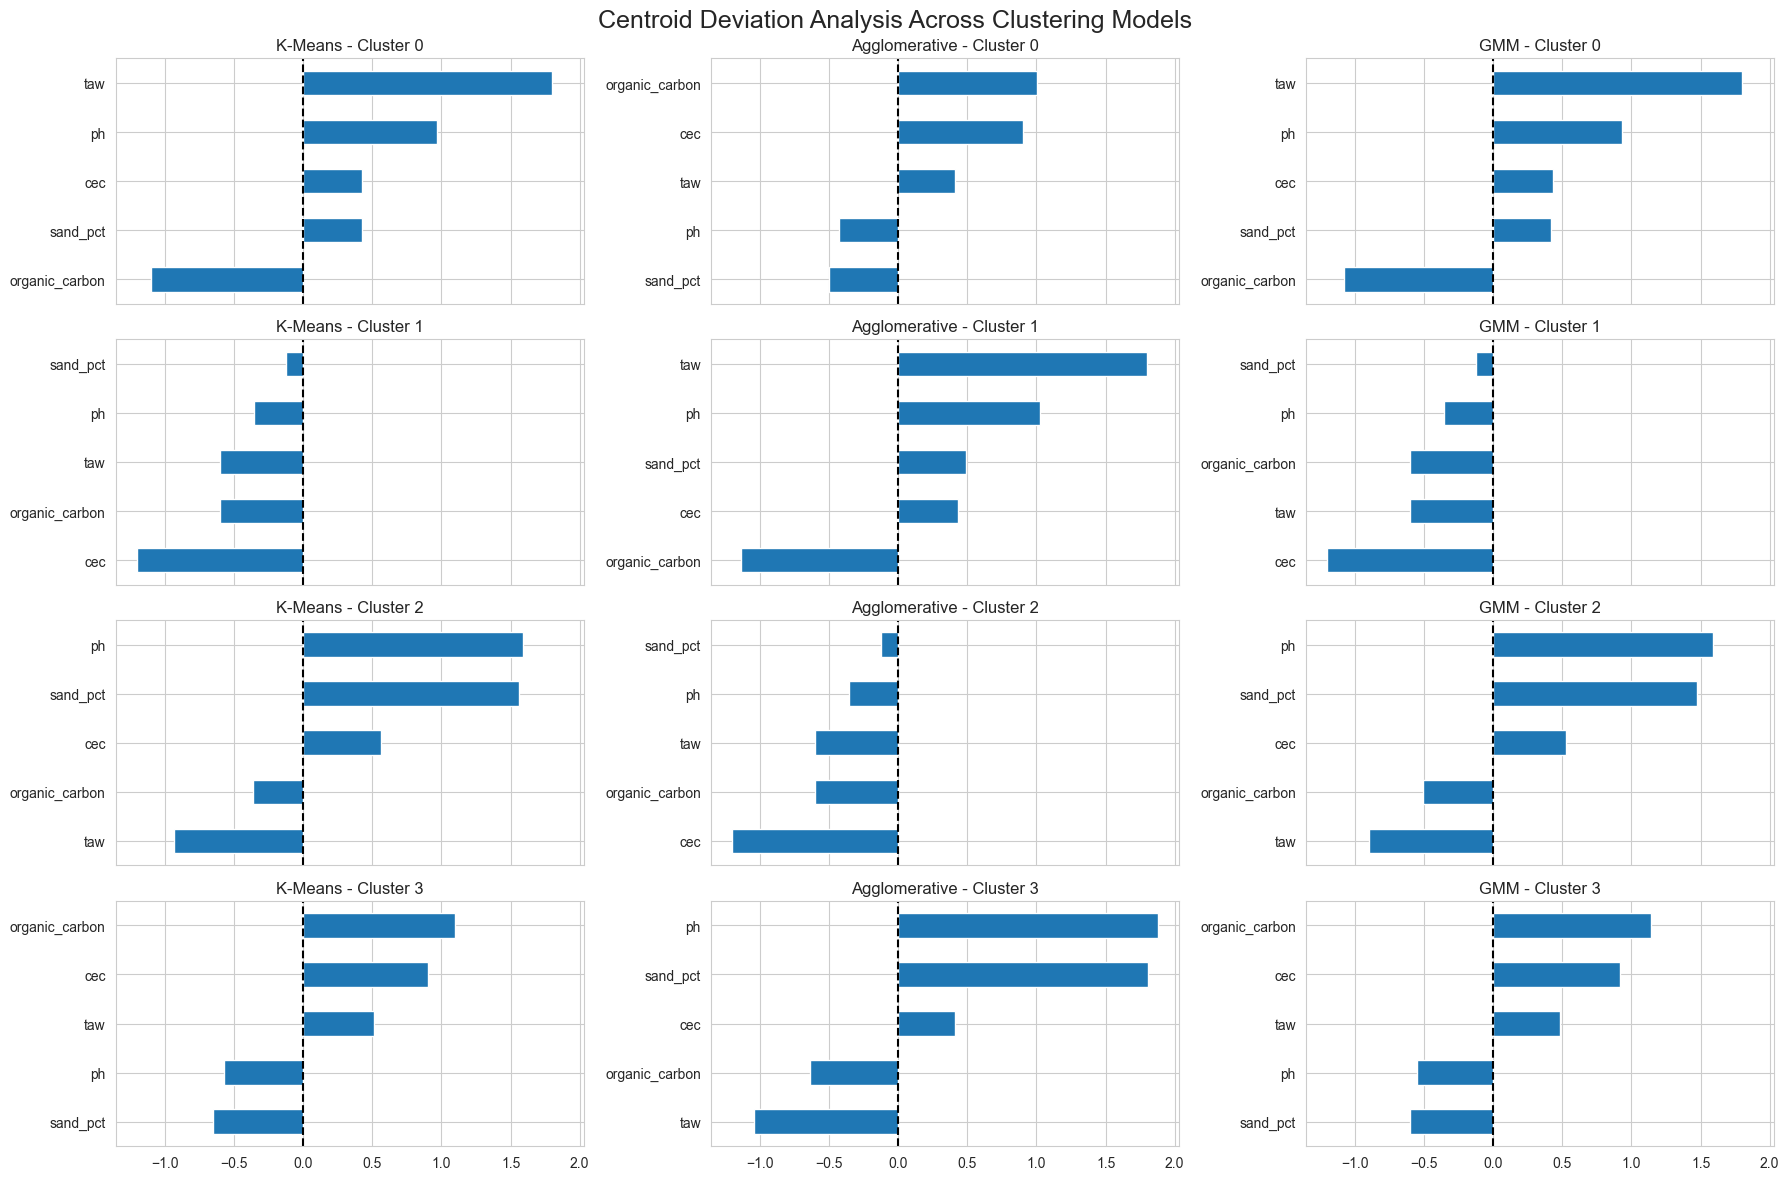

In [44]:
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True)

for col_idx, (model, dev) in enumerate(deviations.items()):
    for row_idx, cluster_id in enumerate(dev.index):
        ax = axes[row_idx, col_idx]
        dev.loc[cluster_id].sort_values().plot.barh(ax=ax)
        ax.axvline(0, color="black", linestyle="--")
        ax.set_title(f"{model} - Cluster {cluster_id}")

plt.suptitle("Centroid Deviation Analysis Across Clustering Models", fontsize=18)
plt.tight_layout()
plt.show()

### **5. Surrogate Decision Tree**

#### **Train Surrogates**

In [45]:
surrogates = {}
fidelities = {}

for model, col in CLUSTER_MODELS.items():
    X = df[FEATURES]
    y = df[col]

    dt = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=50,
        random_state=42
    )

    dt.fit(X, y)
    surrogates[model] = dt
    fidelities[model] = accuracy_score(y, dt.predict(X))

for model, score in fidelities.items():
    print(f"{model} DT Fidelity:", round(score, 3))

K-Means DT Fidelity: 0.987
Agglomerative DT Fidelity: 0.991
GMM DT Fidelity: 0.974


#### **Decision Trees**

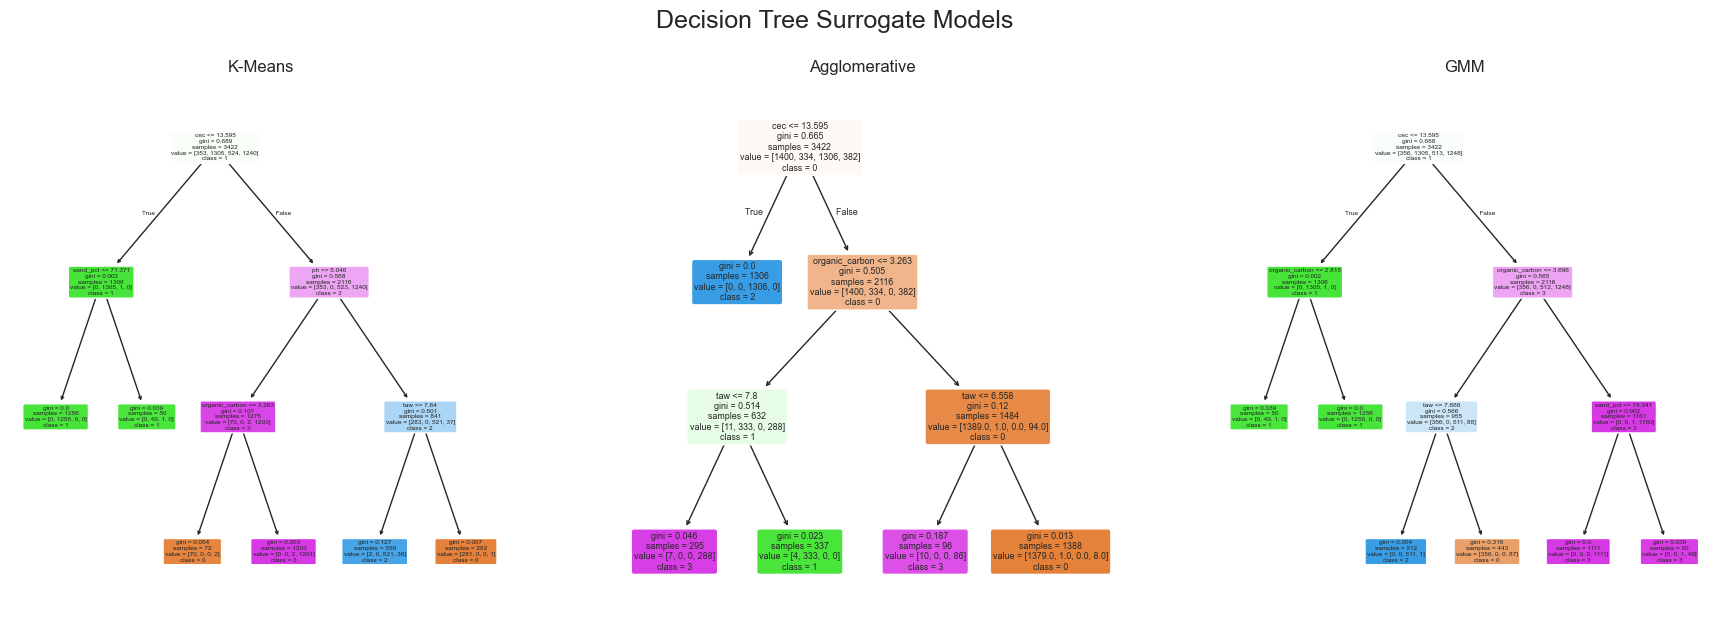

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (model, dt) in zip(axes, surrogates.items()):
    plot_tree(
        dt,
        feature_names=FEATURES,
        class_names=[str(i) for i in sorted(df[CLUSTER_MODELS[model]].unique())],
        filled=True,
        rounded=True,
        ax=ax
    )
    ax.set_title(model)

plt.suptitle("Decision Tree Surrogate Models", fontsize=18)
plt.show()

#### **Rule Extraction**

In [47]:
for model, dt in surrogates.items():
    print("\n" + "="*70)
    print(f"{model} - Decision Rules")
    print("="*70)
    print(export_text(dt, feature_names=FEATURES))


K-Means - Decision Rules
|--- cec <= 13.59
|   |--- sand_pct <= 71.37
|   |   |--- class: 1
|   |--- sand_pct >  71.37
|   |   |--- class: 1
|--- cec >  13.59
|   |--- ph <= 5.05
|   |   |--- organic_carbon <= 3.28
|   |   |   |--- class: 0
|   |   |--- organic_carbon >  3.28
|   |   |   |--- class: 3
|   |--- ph >  5.05
|   |   |--- taw <= 7.64
|   |   |   |--- class: 2
|   |   |--- taw >  7.64
|   |   |   |--- class: 0


Agglomerative - Decision Rules
|--- cec <= 13.59
|   |--- class: 2
|--- cec >  13.59
|   |--- organic_carbon <= 3.26
|   |   |--- taw <= 7.80
|   |   |   |--- class: 3
|   |   |--- taw >  7.80
|   |   |   |--- class: 1
|   |--- organic_carbon >  3.26
|   |   |--- taw <= 6.56
|   |   |   |--- class: 3
|   |   |--- taw >  6.56
|   |   |   |--- class: 0


GMM - Decision Rules
|--- cec <= 13.59
|   |--- organic_carbon <= 2.82
|   |   |--- class: 1
|   |--- organic_carbon >  2.82
|   |   |--- class: 1
|--- cec >  13.59
|   |--- organic_carbon <= 3.70
|   |   |--- taw <= 

#### **Validation Curves**

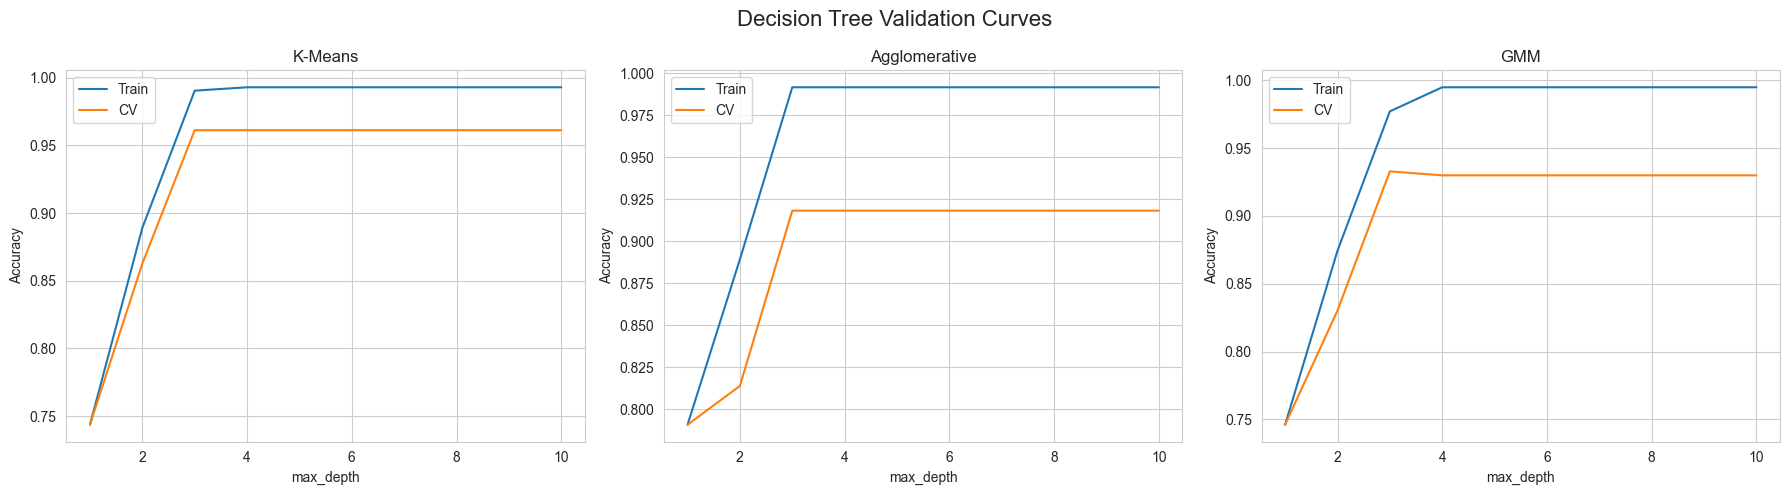

In [48]:
param_range = range(1, 11)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model, col) in zip(axes, CLUSTER_MODELS.items()):
    X = df[FEATURES]
    y = df[col]

    train_scores, test_scores = validation_curve(
        DecisionTreeClassifier(min_samples_leaf=50, random_state=42),
        X, y,
        param_name="max_depth",
        param_range=param_range,
        cv=5,
        scoring="accuracy"
    )

    ax.plot(param_range, train_scores.mean(axis=1), label="Train")
    ax.plot(param_range, test_scores.mean(axis=1), label="CV")
    ax.set_title(model)
    ax.set_xlabel("max_depth")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle("Decision Tree Validation Curves", fontsize=16)
plt.tight_layout()
plt.show()

#### **Learning Curves**

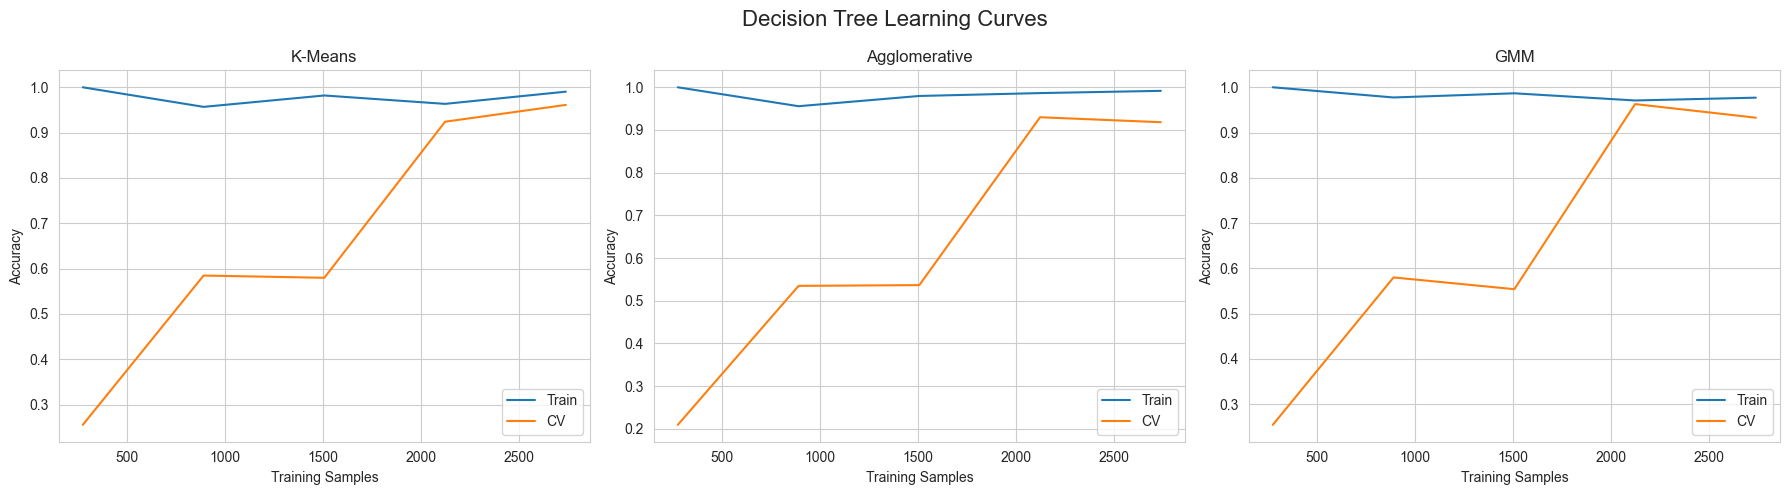

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model, col) in zip(axes, CLUSTER_MODELS.items()):
    X = df[FEATURES]
    y = df[col]

    train_sizes, train_scores, test_scores = learning_curve(
        DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42),
        X, y,
        cv=5,
        scoring="accuracy"
    )

    ax.plot(train_sizes, train_scores.mean(axis=1), label="Train")
    ax.plot(train_sizes, test_scores.mean(axis=1), label="CV")
    ax.set_title(model)
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle("Decision Tree Learning Curves", fontsize=16)
plt.tight_layout()
plt.show()

### **6. Random Forest**

#### **Train Surrogates**

In [50]:
rf_models = {}

for model, col in CLUSTER_MODELS.items():
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    )
    rf.fit(df[FEATURES], df[col])
    rf_models[model] = rf

    print(f"{model} RF Fidelity:",
          round(accuracy_score(df[col], rf.predict(df[FEATURES])), 3))

K-Means RF Fidelity: 0.996
Agglomerative RF Fidelity: 0.999
GMM RF Fidelity: 1.0


#### **Validation Curves**

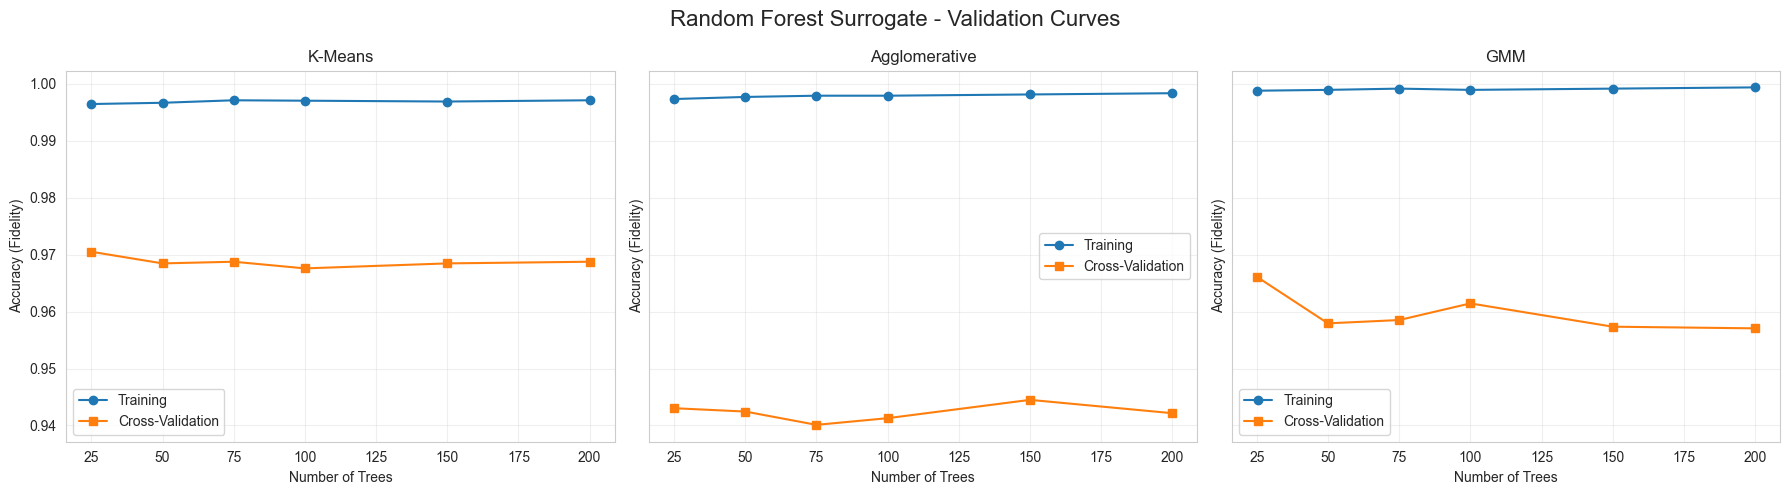

In [51]:
from sklearn.model_selection import validation_curve

param_range_rf = [25, 50, 75, 100, 150, 200]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (model, col) in zip(axes, CLUSTER_MODELS.items()):
    X = df[FEATURES]
    y = df[col]

    train_scores, test_scores = validation_curve(
        RandomForestClassifier(
            max_depth=10,
            min_samples_leaf=20,
            random_state=42
        ),
        X, y,
        param_name="n_estimators",
        param_range=param_range_rf,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    ax.plot(
        param_range_rf,
        train_scores.mean(axis=1),
        marker="o",
        label="Training"
    )
    ax.plot(
        param_range_rf,
        test_scores.mean(axis=1),
        marker="s",
        label="Cross-Validation"
    )

    ax.set_title(model)
    ax.set_xlabel("Number of Trees")
    ax.set_ylabel("Accuracy (Fidelity)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Random Forest Surrogate - Validation Curves",
    fontsize=16
)
plt.tight_layout()
plt.show()

#### **Learning Curves**

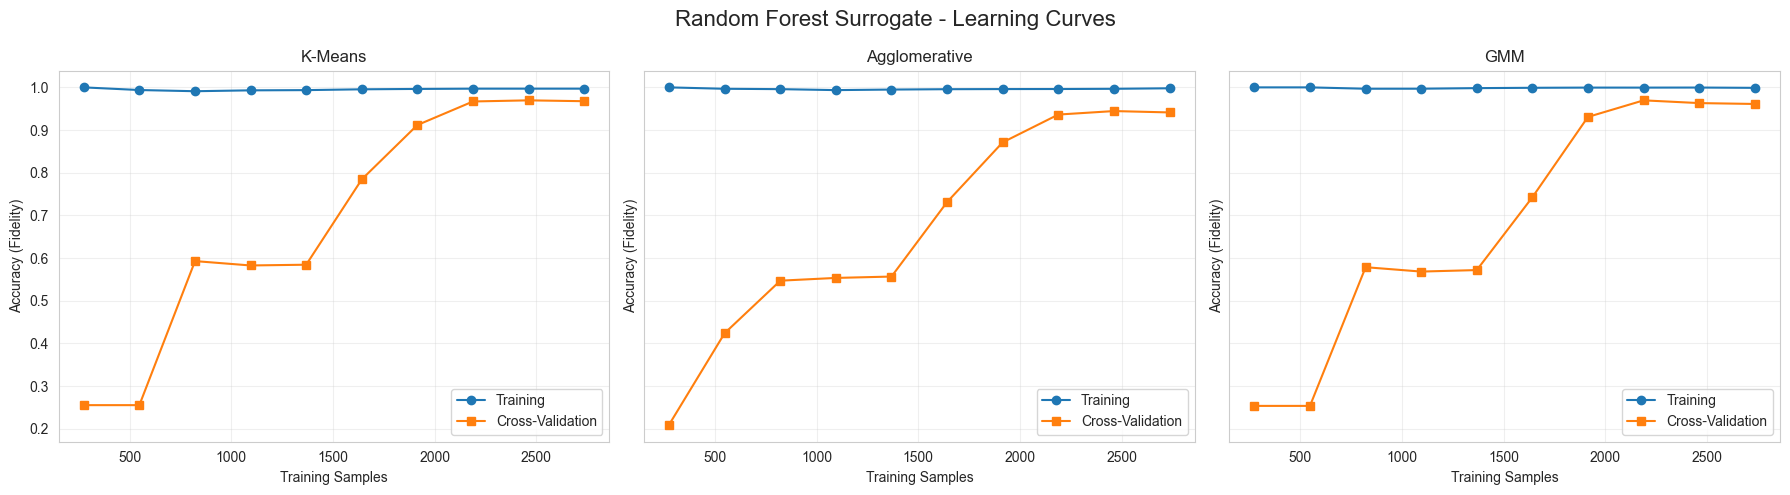

In [52]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (model, col) in zip(axes, CLUSTER_MODELS.items()):
    X = df[FEATURES]
    y = df[col]

    train_sizes, train_scores, test_scores = learning_curve(
        RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_leaf=20,
            random_state=42
        ),
        X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    ax.plot(
        train_sizes,
        train_scores.mean(axis=1),
        marker="o",
        label="Training"
    )
    ax.plot(
        train_sizes,
        test_scores.mean(axis=1),
        marker="s",
        label="Cross-Validation"
    )

    ax.set_title(model)
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Accuracy (Fidelity)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Random Forest Surrogate - Learning Curves",
    fontsize=16
)
plt.tight_layout()
plt.show()

### **7. Surrogate Model Analysis**

Since clustering models (K-Means, Agglomerative, GMM) are difficult to interpret directly, two simpler models, a **Decision Tree** and a **Random Forest** were trained to mimic their behavior.



#### **Decision Tree Surrogate**

| Curve | What Was Tested | What Was Found |
|:------|:----------------|:---------------|
| **Validation Curve** | How tree depth (1-10) affects accuracy | At depth 1-2, the model was too simple and made many errors. Accuracy improved sharply up to depth 3–4, then stopped improving. Going deeper only caused the model to memorize training data without helping on new data. Optimal depth: 3-4 |
| **Learning Curve** | How training data size (300-2700 samples) affects accuracy | With very few samples (~300-500), accuracy on new data was only 20-35%. Performance improved steadily and jumped sharply around 1500–2000 samples, reaching ~92-96% accuracy. The model needs sufficient data to learn cluster patterns. |



#### **Random Forest Surrogate**

| Curve | What Was Tested | What Was Found |
|:------|:----------------|:---------------|
| **Validation Curve** | How number of trees (25-200) affects accuracy | Accuracy remained almost unchanged regardless of how many trees were used. A small forest of 25 trees performed nearly as well as one with 200 trees. The random forest is stable and requires minimal tuning. |
| **Learning Curve** | How training data size (300-2700 samples) affects accuracy | Same pattern as the decision tree, poor performance with few samples, followed by a sharp improvement around 1500–2000 samples. Even a powerful model like random forest cannot overcome a lack of training data. |



#### **Comparison Across Clustering Methods**

| Clustering Method | Decision Tree CV Accuracy | Random Forest CV Accuracy | Ease of Learning |
|:------------------|:-------------------------:|:-------------------------:|:-----------------|
| **K-Means**       | ~96% | ~97% | Highest - clearest cluster boundaries |
| **GMM**           | ~92% | ~96% | Medium - slightly noisier labels |
| **Agglomerative** | ~92% | ~94.5% | Lowest - most ambiguous labels |



#### **Decision Tree vs. Random Forest**

| Aspect | Decision Tree | Random Forest |
|:-------|:-------------:|:--------------:|
| **Best CV Accuracy (K-Means)** | ~96% | ~97% |
| **Sensitivity to Hyperparameters** | High - depth must be tuned carefully | Low - stable across all tree counts |
| **Overfitting Risk** | Moderate | Low |
| **Minimum Data Needed** | ~2000 samples | ~2000 samples |
| **Overall Recommendation** | Good | More robust, preferred choice |



#### **Key Takeaways**

| Finding | Detail |
|:--------|:-------|
| **Main bottleneck** | Amount of training data - both models needed ~2000+ samples to generalize well |
| **Best surrogate model** | Random Forest - slightly more accurate and stable with no tuning required |
| **Best clustering labels** | K-Means - produced the cleanest, most learnable pseudo-labels |
| **Hardest clustering labels** | Agglomerative - most label noise, lowest surrogate accuracy across both models |

### **8. SHAP**

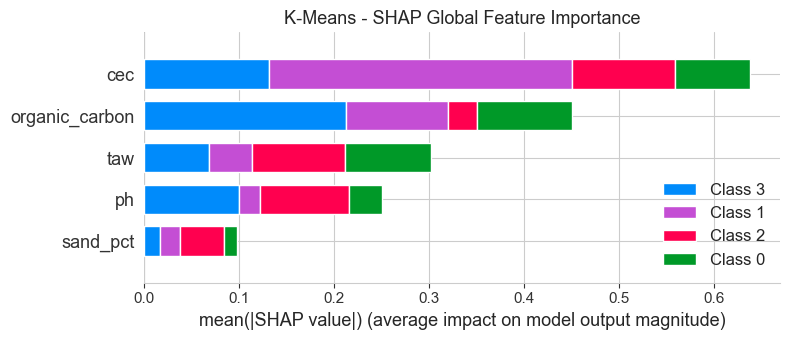

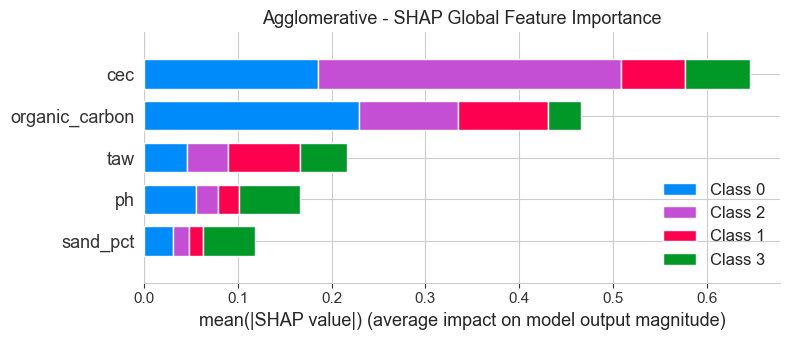

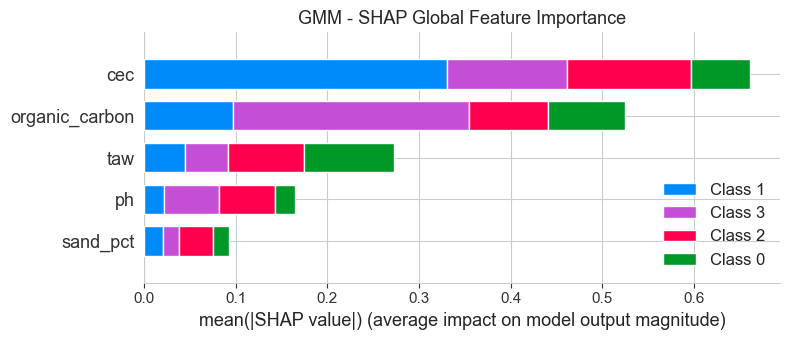

In [53]:
for model, rf in rf_models.items():
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(df[FEATURES])

    plt.figure(figsize=(6, 4))
    shap.summary_plot(
        shap_values,
        df[FEATURES],
        plot_type="bar",
        show=False
    )
    plt.title(f"{model} - SHAP Global Feature Importance", fontsize=13)
    plt.tight_layout()
    plt.show()